In [1]:
from datasets.SyntheticData import SyntheticData

/home/ricca/miniconda3/envs/gkan/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [6]:
from utils.utils import load_config

config = load_config("./configs/config_pred_deriv/config_ic1/config_epidemics.yml")

In [24]:
dataset = SyntheticData(
    root=config['data_folder'],
    dynamics=config['name'],
    t_span=config.get('t_span', (0, 1)),
    t_max=config.get('t_eval_steps', 2000),
    num_samples=config.get('num_samples', -1),
    seed=config['seed'],
    n_ics=config.get('n_iter', 1),
    input_range=config.get('input_range', (0, 1)),
    device=config["device"],
    horizon = config.get('horizon', 15),
    history = config.get('history', 1),
    stride=config.get('stride', 5),
    predict_deriv=True,
    snr_db=20,
    denoise=True,
    **config.get('integration_kwargs', {})
)

Processing...


Building the dataset...


Done!


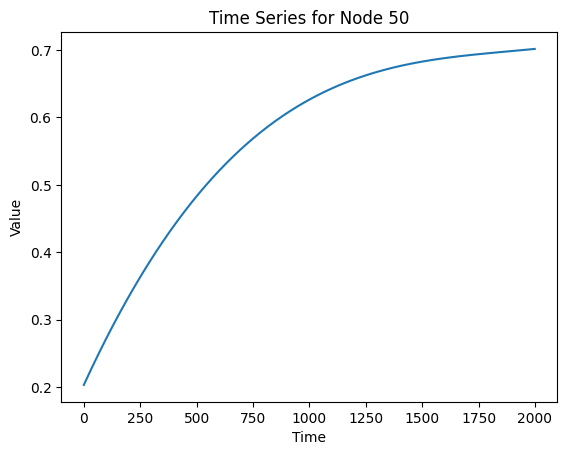

In [25]:
import matplotlib.pyplot as plt

raw_data = dataset.raw_data_sampled[0]
node_id = 50

time_series = raw_data[:, node_id, 0].cpu().numpy()

# Plot
plt.figure()
plt.plot(time_series)
plt.xlabel("Time")
plt.ylabel("Value")
plt.title(f"Time Series for Node {node_id}")
plt.show()
